In [1]:
import sys
from pathlib import Path

# Path to timeskip-diffuser/src
TIMESKIP_SRC = Path("/scratch/network/dd6849/rpmml-project/timeskip-diffuser/src")

if str(TIMESKIP_SRC) not in sys.path:
    sys.path.insert(0, str(TIMESKIP_SRC))

print("Added to sys.path:", TIMESKIP_SRC)

Added to sys.path: /scratch/network/dd6849/rpmml-project/timeskip-diffuser/src


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random
from timeskip_diffuser.diffuser.nets import EqNet, TemporalUNet, TrajNet
from timeskip_diffuser.diffuser.trainer import DiffuserTrainer
from timeskip_diffuser.diffuser.diffusion import GaussianDiffusion
from timeskip_diffuser.diffuser.planner import DiffuserPlanner
from timeskip_diffuser.diffuser.reward import CompositeReward, GoalReachingReward, PathLengthPenalty, StartReachingReward
from timeskip_diffuser.datasets.point_maze.medium import MediumFlatDataset
import torch
from timeskip_diffuser.datasets.point_maze.offline_skip.traj_verifiers.verifier import extract_wall_rects, verify_trajectory_dense, endpoint_within_eps
plt.rcParams['font.family'] = 'serif'
plt.rcParams["font.serif"] = ["DejaVu Serif"]  # always available


In [3]:
net_type = "eqnet"

match net_type:
    case "eqnet":
        net_class = EqNet
        ckpt = "/scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/pipelines/runs/medium_eqnet_seed0_20251221_023939/checkpoints/diffuser_eqnet_epoch_20.pt"
    case "unet":
        net_class = TemporalUNet
        ckpt = "/scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/pipelines/runs/medium_unet_seed0_20251221_030606/checkpoints/diffuser_unet_epoch_20.pt"

In [4]:
# Experiment 1: 
dataset = MediumFlatDataset(horizon=32)
data = np.load("/scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/pointmaze/start_goal/medium_start_goal_100.npz")
starts = data["starts"]
goals  = data["goals"]

assert len(starts) == len(goals)
print(f"Loaded {len(starts)} start-goal pairs")

Loaded 100 start-goal pairs


In [5]:
# Verifier setup (run once per env)
dataset_name = "D4RL/pointmaze/medium-v2"  # adjust per env
wall_rects = extract_wall_rects(dataset_name)

print(f"Loaded {len(wall_rects)} wall rectangles")

Loaded 38 wall rectangles


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = net_class(
    state_dim=dataset.state_dim,
    time_dim=32,
)
diffusion = GaussianDiffusion(timesteps=200)
trainer = DiffuserTrainer(model, diffusion, dataset, lr=1e-4, device=device)
trainer.load_checkpoint(ckpt)
planner = DiffuserPlanner(model, diffusion, dataset, device=device)

Using device: cuda


In [55]:
def run_single_attempt_verified(
    planner,
    current,
    goal,
    wall_rects,
    horizon=32,
    start_eps=0.05,
    goal_eps=0.05,
):
    """
    Uses geometric verification for success:
      - collision-free
      - start & goal within eps
    """

    reward_fn = CompositeReward([
        StartReachingReward(current[:2], reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        PathLengthPenalty(reward_scale=0.2),
    ])

    try:
        traj = planner.plan(
            current, goal,
            horizon=horizon,
            reward_fn=reward_fn,
            guidance_scale=1.0,
            condition_on_start=True,
            condition_on_goal=True,
            conditioning_schedule="constant",
            conditioning_strength=1.0,
        )
    except Exception as e:
        return {
            "success": False,
            "error": "planner_failed",
            "exception": str(e),
        }

    pos_dense = traj[:, :2]

    # --- Verifier checks ---
    collision_free, collision_idx = verify_trajectory_dense(
        pos_dense, wall_rects
    )

    start_ok, goal_ok, start_err, goal_err = endpoint_within_eps(
        pos_dense,
        start_xy=current[:2],
        goal_xy=goal,
        start_eps=start_eps,
        goal_eps=goal_eps,
    )

    success = collision_free and start_ok and goal_ok

    return {
        "success": success,
        "collision_free": collision_free,
        "collision_index": collision_idx,
        "start_ok": start_ok,
        "goal_ok": goal_ok,
        "start_error": float(start_err),
        "goal_error": float(goal_err),
        "trajectory": traj,
    }


In [72]:
def evaluate_pair_verified(
    planner,
    dataset,
    start,
    goal,
    wall_rects,
    num_attempts=5,
):
    """
    Returns:
      feasible: bool
      success_rate: float
      attempts: list of dicts
    """
    attempts = []

    for k in range(num_attempts):
        result = run_single_attempt_verified(
            planner=planner,
            current=start,
            goal=goal,
            wall_rects=wall_rects,
        )
        attempts.append(result)

    successes = [a["success"] for a in attempts if "success" in a]

    success_rate = np.mean(successes) if len(successes) > 0 else 0.0
    feasibility  = any(successes)

    return {
        "feasible": feasibility,
        "success_rate": success_rate,
        "attempts": attempts,
    }


In [73]:
import numpy as np

def evaluate_env_arch_verified(
    planner,
    dataset,
    starts,
    goals,
    wall_rects,
    num_attempts=5,
):
    """
    Runs num_attempts per (start, goal) pair.
    
    Metrics:
      - Feasible: at least one successful attempt
      - Success rate: fraction of successful attempts

    Returns:
      summary dict with per-pair + aggregate metrics
    """
    results = []

    for i, (start, goal) in enumerate(zip(starts, goals)):
        out = evaluate_pair_verified(
            planner=planner,
            dataset=dataset,
            start=start,
            goal=goal,
            wall_rects=wall_rects,
            num_attempts=num_attempts,
        )
        results.append(out)

        print(
            f"[{i:03d}] "
            f"Feasible={out['feasible']} | "
            f"SuccessRate={out['success_rate']:.2f}"
        )

    feasibility_rate = np.mean([r["feasible"] for r in results])
    avg_success_rate = np.mean([r["success_rate"] for r in results])

    summary = {
        "feasibility_rate": feasibility_rate,
        "avg_success_rate": avg_success_rate,
        "per_pair": results,
    }

    return summary


In [74]:
def get_one_success_traj(pair_result):
    """
    pair_result: one entry from summary["per_pair"]

    Returns:
        trajectory or None
    """
    for attempt in pair_result["attempts"]:
        if attempt.get("success", False):
            return attempt["trajectory"]
    return None


=== SINGLE ATTEMPT (VERIFIED) ===
Success          : False
Start OK         : True
Goal OK          : True
Start error      : 0.0001
Goal error       : 0.0006
Collision-free   : False
First collision @ index 8


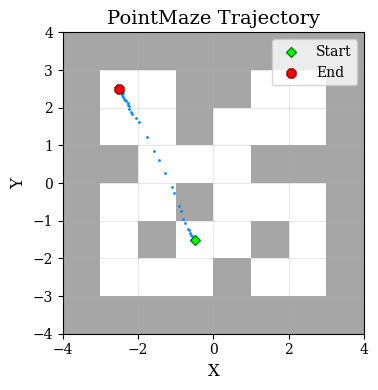

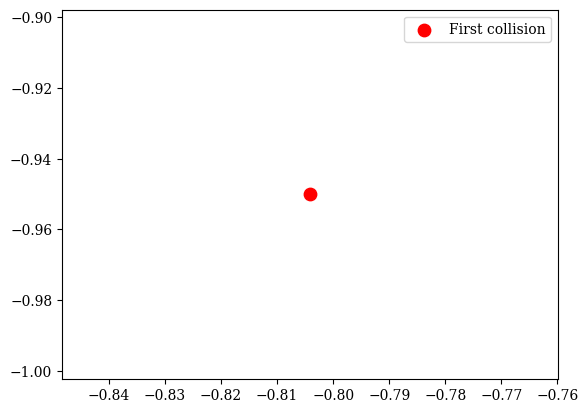

In [75]:
# ---- One-attempt debug cell (using run_single_attempt_verified) ----

# Required inputs already defined:
# planner, dataset
# start (D,), goal (2,)
# wall_rects
start = [-0.5, -1.5]
goal = [-2.5,  2.5]
result = run_single_attempt_verified(
    planner=planner,
    current=start,
    goal=goal,
    wall_rects=wall_rects,
    horizon=32,
    start_eps=0.05,
    goal_eps=0.05,
)

print("=== SINGLE ATTEMPT (VERIFIED) ===")
print(f"Success          : {result['success']}")
print(f"Start OK         : {result.get('start_ok', False)}")
print(f"Goal OK          : {result.get('goal_ok', False)}")
print(f"Start error      : {result.get('start_error', float('nan')):.4f}")
print(f"Goal error       : {result.get('goal_error', float('nan')):.4f}")
print(f"Collision-free   : {result.get('collision_free', False)}")

if not result.get("collision_free", True):
    print(f"First collision @ index {result['collision_index']}")

# ---- Visualization ----
if "trajectory" in result:
    dataset.visualize(result["trajectory"])

    # Mark first collision point on SAME axes
    if not result.get("collision_free", True):
        import matplotlib.pyplot as plt

        ax = plt.gca()  # get current axes used by dataset.visualize
        idx = result["collision_index"]
        p = result["trajectory"][idx, :2]

        ax.scatter(
            p[0], p[1],
            c="red",
            s=80,
            zorder=10,
            label="First collision"
        )
        ax.legend()
else:
    print("No trajectory returned (planner failure)")


In [77]:
summary = evaluate_env_arch_verified(
    planner=planner,
    dataset=dataset,
    starts=starts,
    goals=goals,
    wall_rects=wall_rects,
    num_attempts=5,
)

print("\n=== FINAL METRICS ===")
print(f"Feasibility rate    : {summary['feasibility_rate']:.3f}")
print(f"Average success rate: {summary['avg_success_rate']:.3f}")


[000] Feasible=True | SuccessRate=1.00
[001] Feasible=True | SuccessRate=0.80
[002] Feasible=False | SuccessRate=0.00
[003] Feasible=True | SuccessRate=0.60
[004] Feasible=False | SuccessRate=0.00
[005] Feasible=True | SuccessRate=1.00
[006] Feasible=False | SuccessRate=0.00
[007] Feasible=True | SuccessRate=0.20
[008] Feasible=False | SuccessRate=0.00
[009] Feasible=True | SuccessRate=1.00
[010] Feasible=True | SuccessRate=1.00
[011] Feasible=False | SuccessRate=0.00
[012] Feasible=False | SuccessRate=0.00
[013] Feasible=False | SuccessRate=0.00
[014] Feasible=False | SuccessRate=0.00
[015] Feasible=True | SuccessRate=1.00
[016] Feasible=False | SuccessRate=0.00
[017] Feasible=False | SuccessRate=0.00
[018] Feasible=True | SuccessRate=1.00
[019] Feasible=False | SuccessRate=0.00
[020] Feasible=True | SuccessRate=1.00
[021] Feasible=True | SuccessRate=1.00
[022] Feasible=True | SuccessRate=0.40
[023] Feasible=False | SuccessRate=0.00
[024] Feasible=True | SuccessRate=0.20
[025] Feasibl


=== Pair 000 ===
Feasible: True
Success rate: 1.00


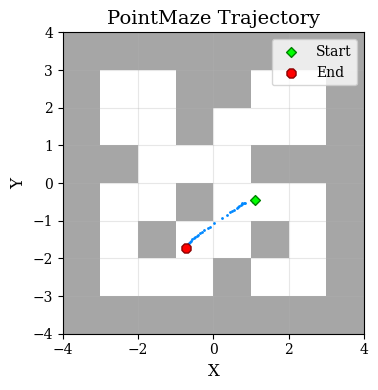


=== Pair 001 ===
Feasible: True
Success rate: 0.80


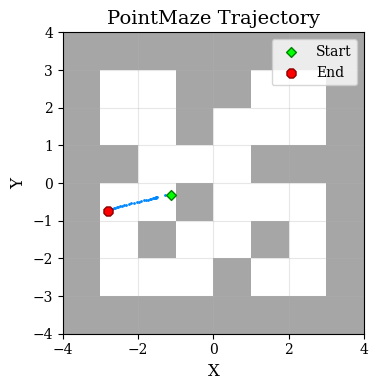


=== Pair 002 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 003 ===
Feasible: True
Success rate: 0.60


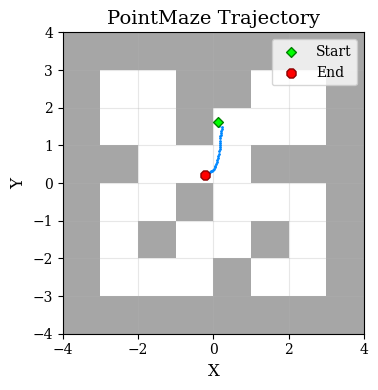


=== Pair 004 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 005 ===
Feasible: True
Success rate: 1.00


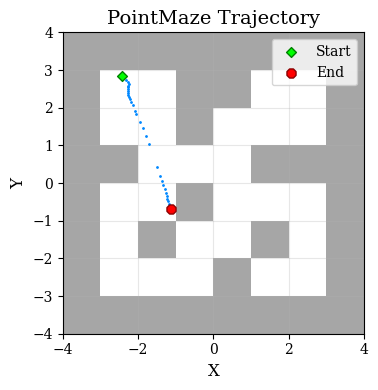


=== Pair 006 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 007 ===
Feasible: True
Success rate: 0.20


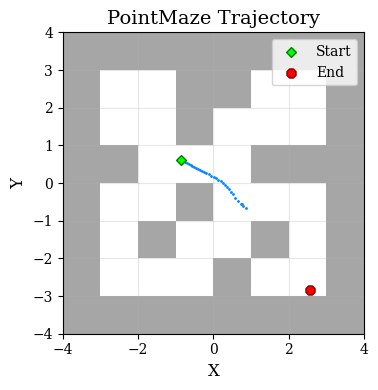


=== Pair 008 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 009 ===
Feasible: True
Success rate: 1.00


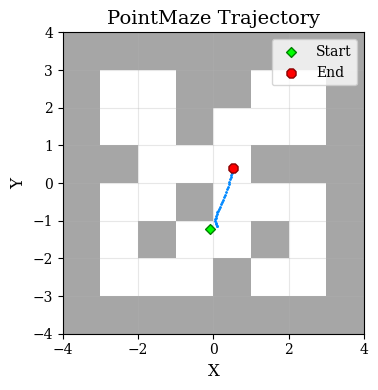


=== Pair 010 ===
Feasible: True
Success rate: 1.00


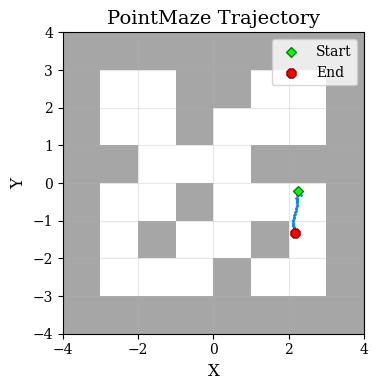


=== Pair 011 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 012 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 013 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 014 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 015 ===
Feasible: True
Success rate: 1.00


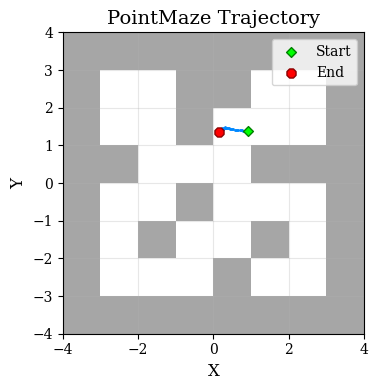


=== Pair 016 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 017 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 018 ===
Feasible: True
Success rate: 1.00


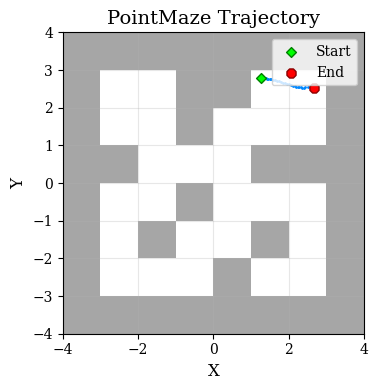


=== Pair 019 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 020 ===
Feasible: True
Success rate: 1.00


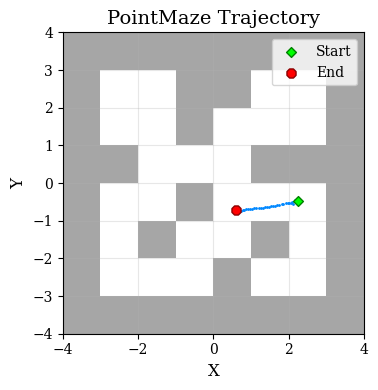


=== Pair 021 ===
Feasible: True
Success rate: 1.00


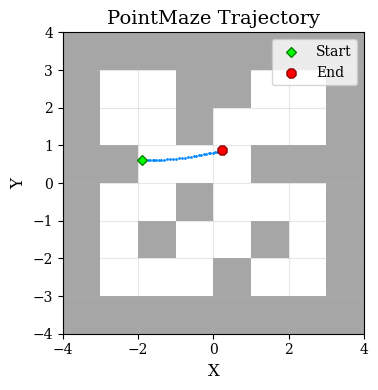


=== Pair 022 ===
Feasible: True
Success rate: 0.40


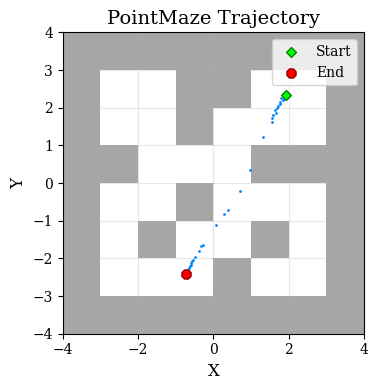


=== Pair 023 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 024 ===
Feasible: True
Success rate: 0.20


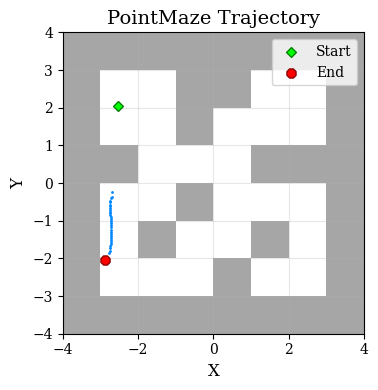


=== Pair 025 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 026 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 027 ===
Feasible: True
Success rate: 0.40


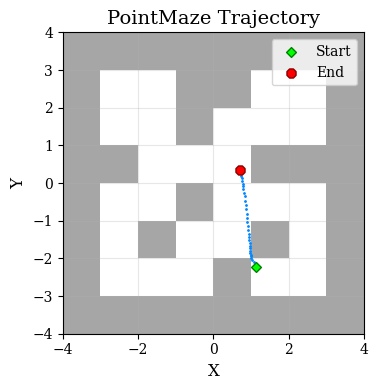


=== Pair 028 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 029 ===
Feasible: True
Success rate: 1.00


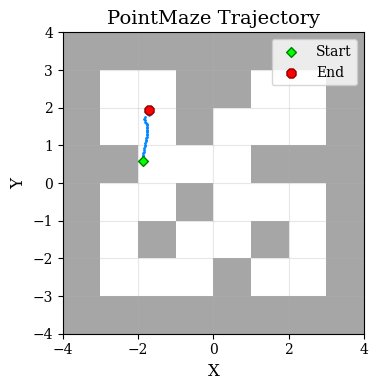


=== Pair 030 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 031 ===
Feasible: True
Success rate: 1.00


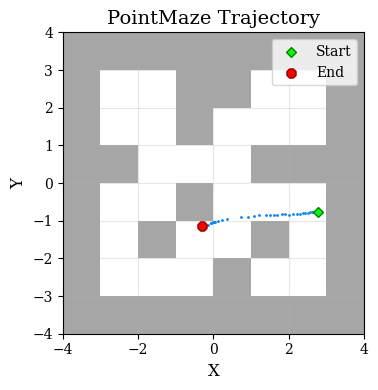


=== Pair 032 ===
Feasible: True
Success rate: 1.00


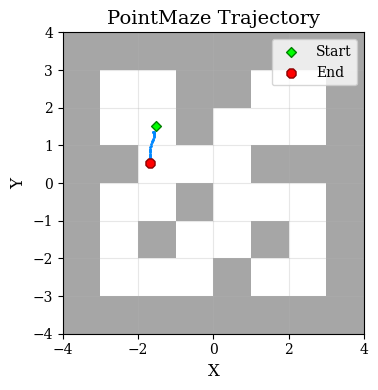


=== Pair 033 ===
Feasible: True
Success rate: 0.40


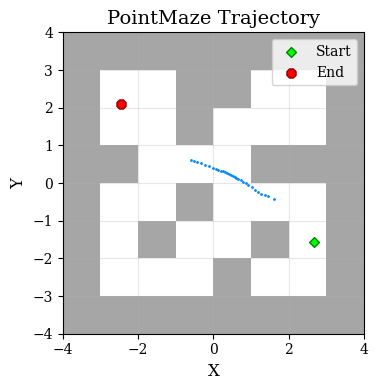


=== Pair 034 ===
Feasible: True
Success rate: 1.00


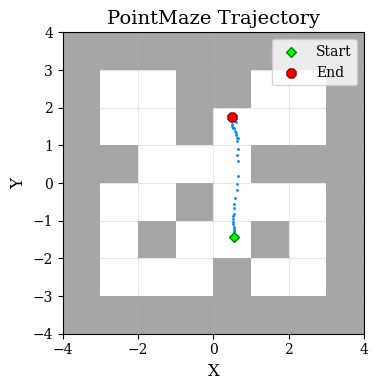


=== Pair 035 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 036 ===
Feasible: True
Success rate: 1.00


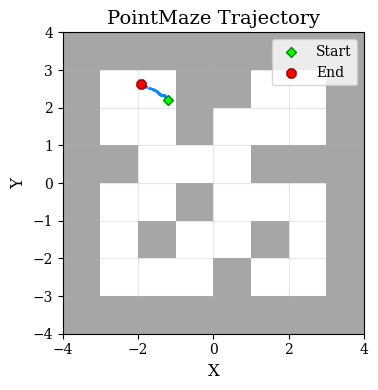


=== Pair 037 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 038 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 039 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 040 ===
Feasible: True
Success rate: 1.00


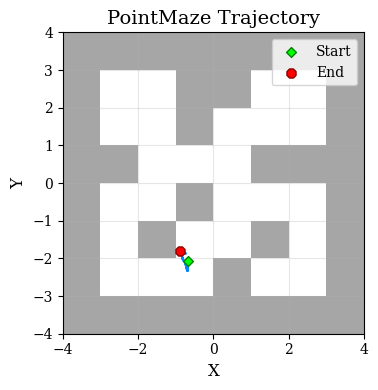


=== Pair 041 ===
Feasible: True
Success rate: 0.20


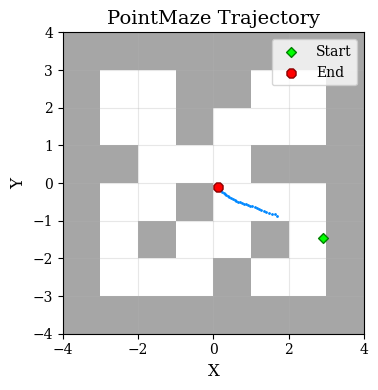


=== Pair 042 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 043 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 044 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 045 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 046 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 047 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 048 ===
Feasible: True
Success rate: 0.20


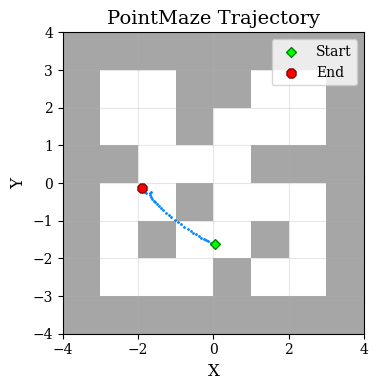


=== Pair 049 ===
Feasible: True
Success rate: 1.00


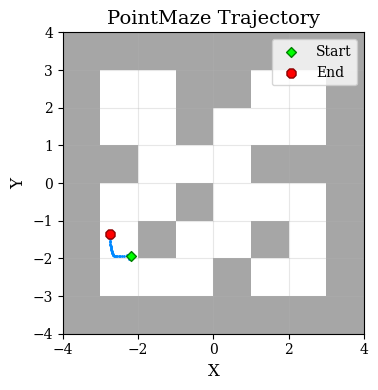


=== Pair 050 ===
Feasible: True
Success rate: 0.40


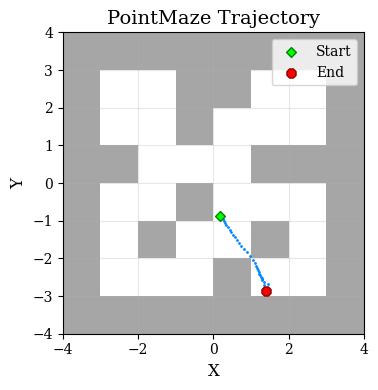


=== Pair 051 ===
Feasible: True
Success rate: 0.40


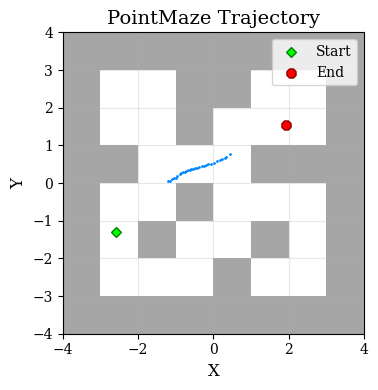


=== Pair 052 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 053 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 054 ===
Feasible: True
Success rate: 0.80


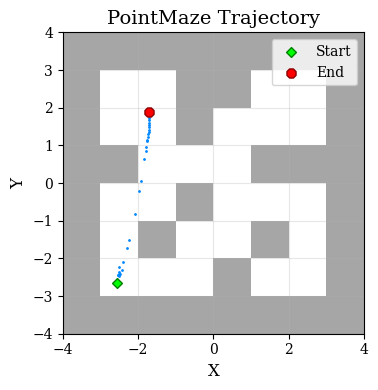


=== Pair 055 ===
Feasible: True
Success rate: 0.20


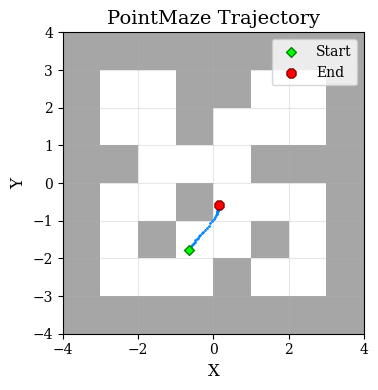


=== Pair 056 ===
Feasible: True
Success rate: 1.00


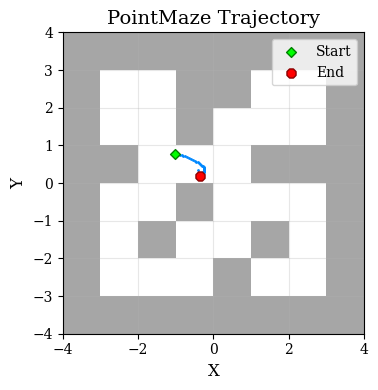


=== Pair 057 ===
Feasible: True
Success rate: 1.00


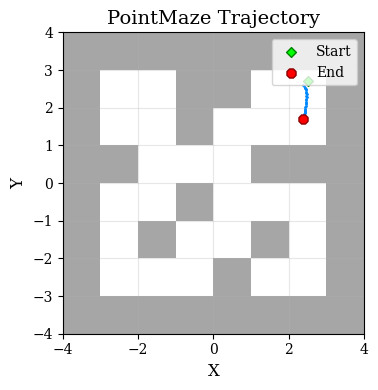


=== Pair 058 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 059 ===
Feasible: True
Success rate: 0.80


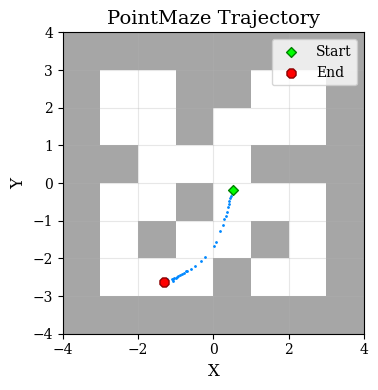


=== Pair 060 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 061 ===
Feasible: True
Success rate: 1.00


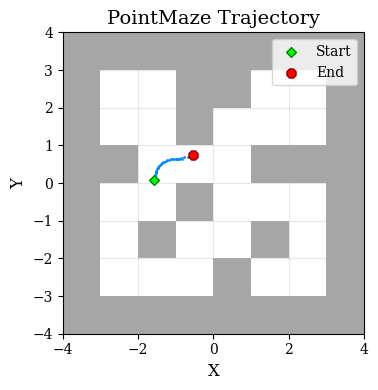


=== Pair 062 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 063 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 064 ===
Feasible: True
Success rate: 0.20


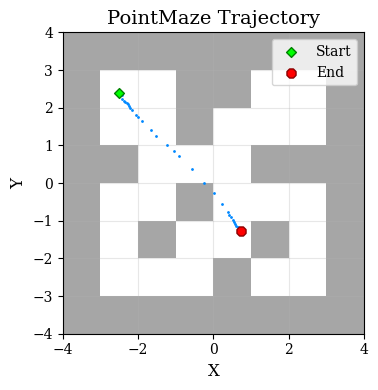


=== Pair 065 ===
Feasible: True
Success rate: 1.00


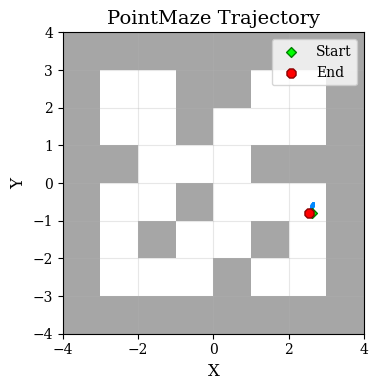


=== Pair 066 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 067 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 068 ===
Feasible: True
Success rate: 1.00


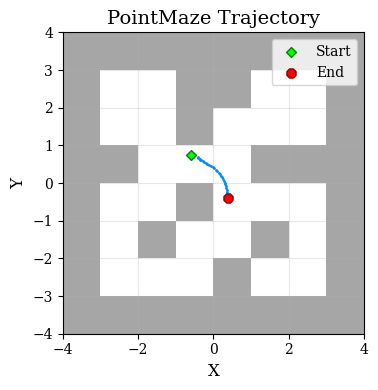


=== Pair 069 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 070 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 071 ===
Feasible: True
Success rate: 0.20


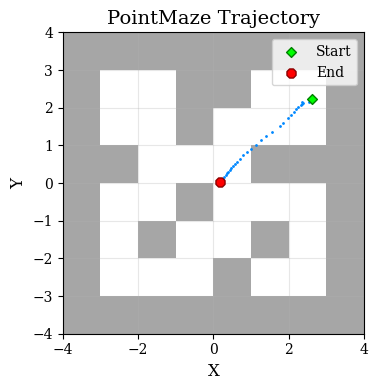


=== Pair 072 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 073 ===
Feasible: True
Success rate: 0.60


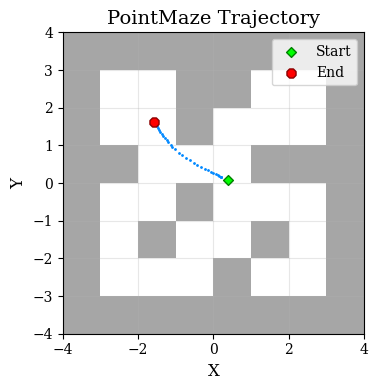


=== Pair 074 ===
Feasible: True
Success rate: 0.20


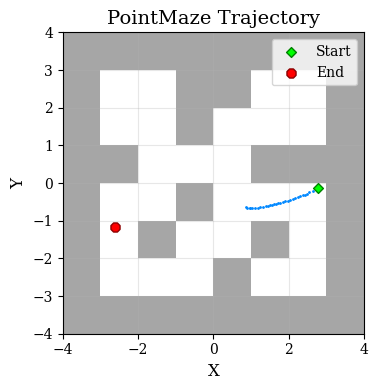


=== Pair 075 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 076 ===
Feasible: True
Success rate: 1.00


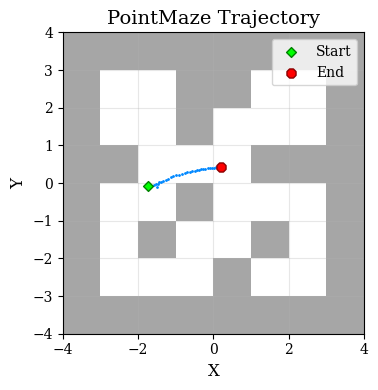


=== Pair 077 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 078 ===
Feasible: True
Success rate: 0.20


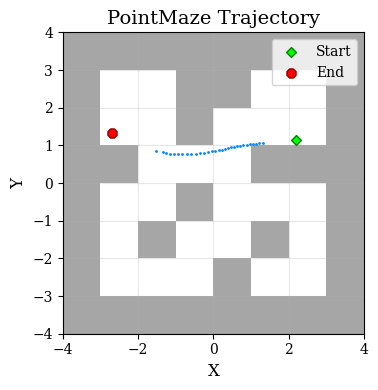


=== Pair 079 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 080 ===
Feasible: True
Success rate: 1.00


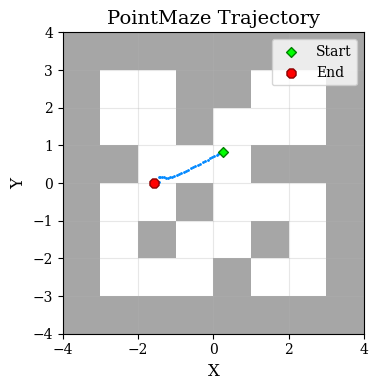


=== Pair 081 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 082 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 083 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 084 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 085 ===
Feasible: True
Success rate: 1.00


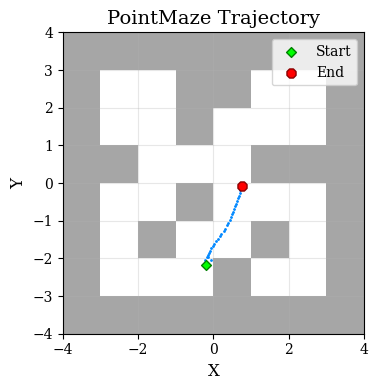


=== Pair 086 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 087 ===
Feasible: True
Success rate: 0.20


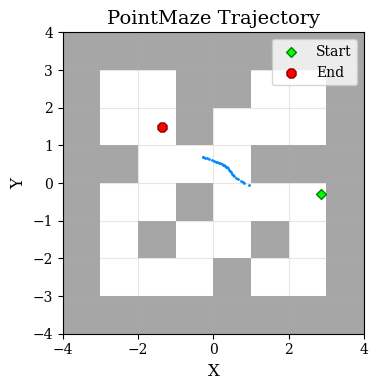


=== Pair 088 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 089 ===
Feasible: True
Success rate: 0.60


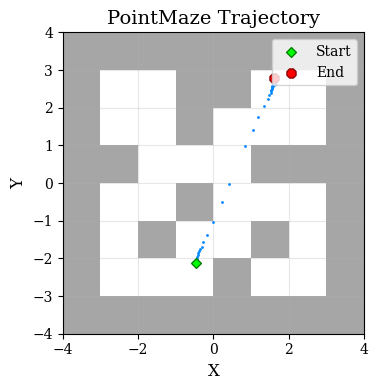


=== Pair 090 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 091 ===
Feasible: True
Success rate: 1.00


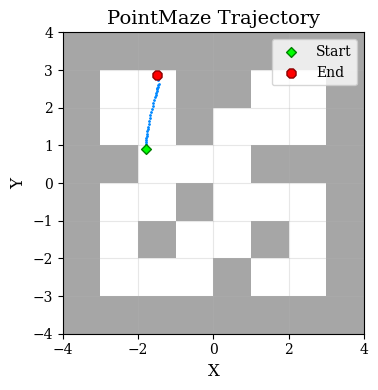


=== Pair 092 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 093 ===
Feasible: True
Success rate: 1.00


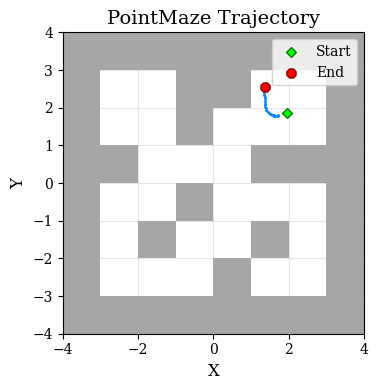


=== Pair 094 ===
Feasible: True
Success rate: 1.00


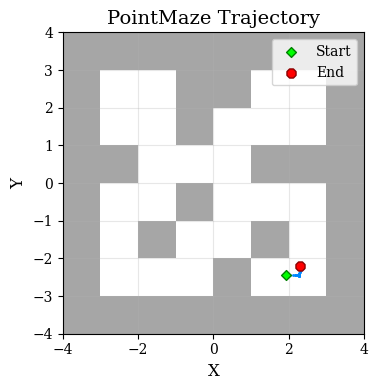


=== Pair 095 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 096 ===
Feasible: True
Success rate: 0.40


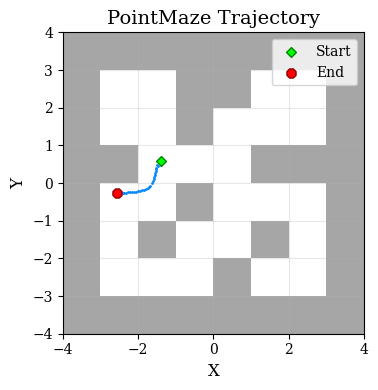


=== Pair 097 ===
Feasible: False
Success rate: 0.00
❌ No successful trajectory found

=== Pair 098 ===
Feasible: True
Success rate: 0.60


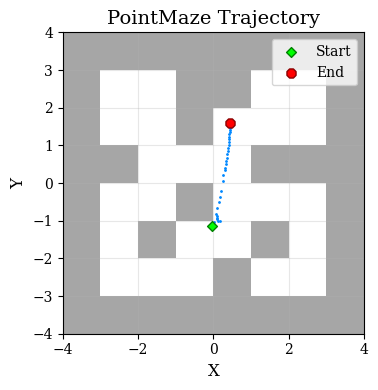


=== Pair 099 ===
Feasible: True
Success rate: 0.80


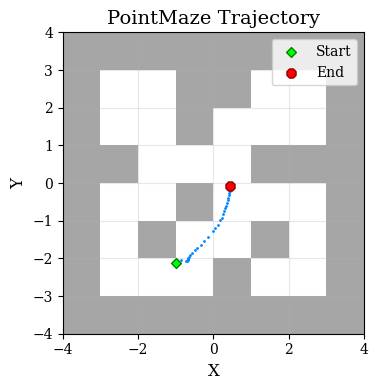

In [78]:
def visualize_one_success_per_pair(summary, dataset):
    for i, pair in enumerate(summary["per_pair"]):
        traj = get_one_success_traj(pair)

        print(f"\n=== Pair {i:03d} ===")
        print(f"Feasible: {pair['feasible']}")
        print(f"Success rate: {pair['success_rate']:.2f}")

        if traj is None:
            print("❌ No successful trajectory found")
            continue

        dataset.visualize(traj)
        
visualize_one_success_per_pair(summary, dataset)


In [79]:
out_path = Path("/scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/metrics/summary_medium_eqnet_flat.npz")
out_path.parent.mkdir(parents=True, exist_ok=True)

np.savez(
    out_path,
    # inputs
    starts=starts,              # (N, 2)
    goals=goals,                # (N, 2)
    wall_rects=np.array(wall_rects),

    # summary metrics
    feasibility_rate=summary["feasibility_rate"],
    avg_success_rate=summary["avg_success_rate"],

    # optional per-episode stats if present
    successes=summary.get("successes"),
    attempts=summary.get("attempts"),

    # metadata (safe to store as scalars / strings)
    env="medium",
    architecture="eqnet",
    horizon=32,
    num_attempts=5,
)

print(f"Saved evaluation results to {out_path}")

Saved evaluation results to /scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/metrics/summary_medium_eqnet_flat.npz


KeysView(NpzFile '/scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/datasets/offline_datasets/medium_h32_mu1_sig1.npz' with keys: data, flat_mean, flat_std, skip_mean, skip_std...)
